# Curvature Exploration
**New notebook to explore different curvature definitions and their application to known datasets**

## 1. Imports

In [233]:
# system
import os

# standard data science libraries
import numpy as np
import pandas as pd

# plotting
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

# core machine learning library
import torch

## 2. Selective data import & manipulation

In [234]:
# parameters for data retrieval and model training
stalk_dim = 1
hidden_channels = 16
dataset = "texas"
layers = 2
epochs = 500
fold = 0

# storing learned maps and laplacians from the experiments
maps, laplacians = [], []
for layer in range(layers):
    # load maps and laplacian for each provided layer
    maps_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold{fold}_seed43.pt"
    laplacian_path = f"../results/laplacians/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold{fold}_seed43.pt"
    maps.append(torch.load(maps_path))
    laplacians.append(torch.load(laplacian_path))

### 2.1 Maps

In [235]:
# storing maps as pandas dataframes for easier analysis
maps_dfs = []
for map_item in maps:
    map_df = pd.DataFrame(map_item.cpu().tolist(), columns=["source", "target", "map_value"])
    map_df[["source", "target"]] = map_df[["source", "target"]].astype(int)
    map_df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    maps_dfs.append(map_df)

### 2.2 Laplacians

In [236]:
# storing laplacians as pandas dataframes for easier analysis
# currently in source-, target- and value-rows format -> need to pivot
laplacians_dfs = []
for laplacian in laplacians:
    laplacian_df = pd.DataFrame(laplacian.cpu().tolist())
    laplacians_dfs.append(laplacian_df)

***l0 = node-level laplacian, l1 = edge-level laplacian***

here, we define lists for:
1. l0_list_paper: the 0-Laplacian as reconstructed from the paper's provided dataframes (pivoting the source-target-value format)
2. l0_list: the 0-Laplacian as computed from the incidence matrix (B @ B.T, as per Hodge)
3. l1_list: the 1-Laplacian as computed from the incidence matrix (B.T @ B, as per Hodge)
4. Incidence matrices

In [237]:
l0_list_paper, l0_list, l1_list = [], [], []
incidence_matrices_list = []

# for 0-Laplacian as in the paper, we reconstruct the matrix by pivoting our current df
for lap in laplacians_dfs:
    df = lap.transpose().copy()
    df.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
    df_new = df.pivot(index="source", columns="target", values="value").fillna(0)
    l0 = df_new.to_numpy()
    l0_list_paper.append(l0)

# for 0-Laplacian, 1-Laplacian computed from scratch, we need maps matrix manipulation
for map_df in maps_dfs:
    
    df = map_df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

    df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])), axis=1)
    
    nodes = sorted(set(df["source"]).union(set(df["target"])))
    edges = sorted(set(df["edge"]))

    B = df.pivot(index="source", columns="edge", values="signed_map").fillna(0).to_numpy()
    B_pd = df.pivot(index="source", columns="edge", values="signed_map").fillna(0)
    
    # display(B_pd)

    incidence_matrices_list.append(B_pd)

    l0 = B @ B.T
    l0_list.append(l0)

    l1 = B.T @ B
    l1_list.append(l1)

### 2.3 Degree Matrices

In [238]:
# display(np.count_nonzero(B[0]))
# the degree matrix D is a diagonal matrix where D[i,i] is the degree of node i, which can be computed as the count of non-zero values of the entries in the corresponding row of B

D = np.diag(np.count_nonzero(B, axis=1))
# display(D)

# the true matrix used for normalization is D_tilde = D + I
D_augmented = D + np.eye(D.shape[0])
# display(D_augmented)

# Now we invert, in order to compute the actually used normalisation matrices D^{-1/2} and D^{-1}
D_augmented_inv = np.linalg.inv(D_augmented)
D_augmented_inv_sqrt = np.linalg.inv(np.sqrt(D_augmented))
# display(D_augmented_inv)
# display(D_augmented_inv_sqrt)

## 3. Curvature Computation

### 3.1 Bochner-Weitzenbock decomposition

In [239]:
# formula to decompose the laplacian L into B + F:
# 1. B = combinatorial Bochner Laplacian (strongly non-negative)
# 2. F = combinatorial curvature term (diagonal matrix)

def fbc(L):
    
    l=L.shape[0]
    B=L.copy()
    
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])

    F = L - B
    
    return B , F

In [240]:
# applying the BW decomposition to the laplacians, storing curvature terms
# curvature here is the combinatorial Ricci curvature, ie the diagonal F
# Ricci-curvature is only defined for edge-based Laplacians, otherwise it is an abuse of notation for k-combinatorial curvature term

fbc_curvature_paper_l0_list = [fbc(l0)[1] for l0 in l0_list_paper]
fbc_curvature_l0_list = [fbc(l0)[1] for l0 in l0_list]
fbc_curvature_l1_list = [fbc(l1)[1] for l1 in l1_list]

### 3.2 Forman-Weber Curvature Formula

![Curvature](../quick_analysis/images/ricci_weber_curvature.png)

In [241]:
def forman_weber_curvature(L: np.ndarray, degree_weights = False) -> dict:
    
    """
    Compute the Forman-Weber curvature for a given Laplacian and incidence matrix.
    Inputs:
    - L: the Laplacian matrix, n x n np.ndarray
    - degree_weights: boolean, whether to use degrees as nodes weights (default: False)
    
    Outputs:
    - curvature_dict: dictionary w/ edge (input, output)-tuple keys, curvature values
    """
    
    # 1. edge-weights
    edge_weights = np.abs(L)

    # 2. node-weights
    if degree_weights:

        # take the Laplacian matrix, compute degree matrix D
        # D + I augmentation is not needed, as the vv-entry is non-zero
        # then invert and take absolute values for node weights

        D = np.diag(np.count_nonzero(L, axis=1))
        node_weights = np.diag(np.linalg.inv(D))

    else:

        node_weights = abs(np.diag(L))

    # print("edge weights:\n", edge_weights, "\n", "type:", type(edge_weights), "\n", "shape:", edge_weights.shape)
    # print("node weights:\n", node_weights, "\n", "type:", type(node_weights), "\n", "shape:", node_weights.shape)

    # 3. curvature computation
    curvature_dict = {}
    for i in range(L.shape[0]):
        for j in range(L.shape[1]):
            if (i != j and L[i, j] != 0) and (i < j):
                edge_key = (i, j)

                # first term: weight(i) / weight(i,j)
                term1 = node_weights[i] / edge_weights[i, j]

                # second term: weight(j) / weight(i,j)
                term2 = node_weights[j] / edge_weights[i, j]

                # third term: sum_{over edges k incident to i} of weight of i / sqrt(weight(i,j) * weight(i,k))
                term3 = 0
                for k in range(L.shape[1]):
                    if k != j and L[i,k] != 0:
                        if i < k:
                            term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[i, k])
                        else:
                            term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[k, i])
                
                # fourth term: sum_{over edges k incident to j} of weight of j / sqrt(weight(i,j) * weight(j,k))
                term4 = 0
                for k in range(L.shape[1]):
                    if k != i and L[j,k] != 0:
                        if j < k:
                            term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[j, k])
                        else:
                            term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[k, j])

                # summing up the terms and multiplying by the edge weight
                curvature_dict[edge_key] = (term1 + term2 - term3 - term4)
                # curvature_dict[edge_key] = edge_weights[i, j] * (term1 + term2 - term3 - term4)
    
    return curvature_dict
    

### 3.3 FW Curvature plotting

In [242]:
# general parameters for the experiments
layer = 0

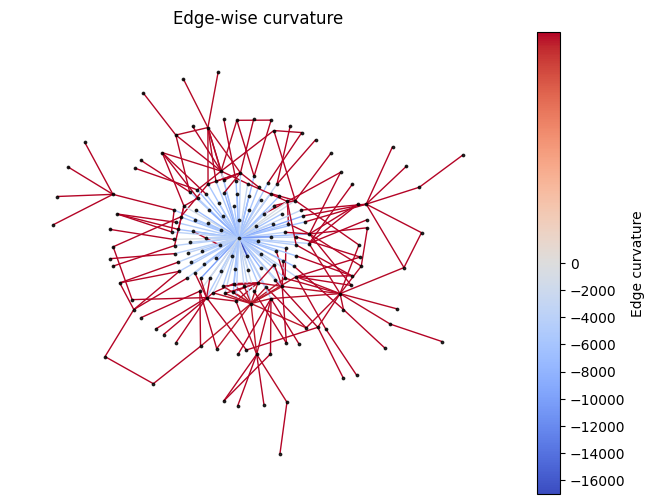

In [243]:
# Idea 1
# Edge weights_{vu} := abs(uv-entry of the normalized Laplacian), ie.: the l0_paper uv-entry
# Node weights_{v} := abs(vv-entry of the normalized Laplacian), ie.: the l0_paper vv-entry

# plotting for a single-layer laplacian
curvature_dict_l0_paper = forman_weber_curvature(l0_list_paper[layer], degree_weights=False)
# display(curvature_dict_l0_paper)

G = nx.Graph()
G.add_nodes_from(range(l0_list_paper[layer].shape[0]))
G.add_edges_from(sorted(curvature_dict_l0_paper.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0_paper[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

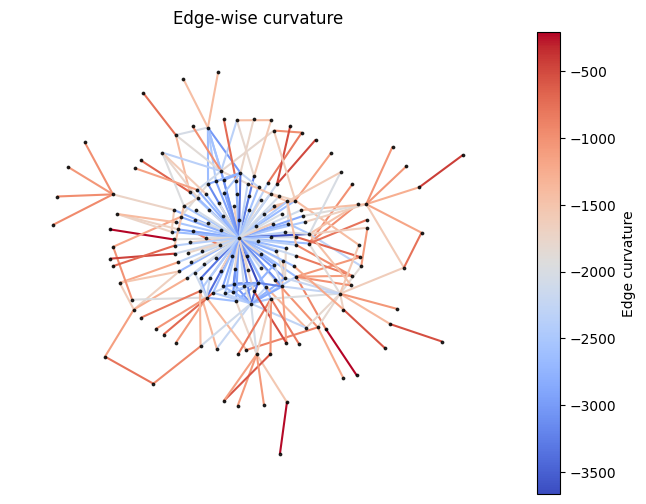

In [244]:
# Idea 2
# Edge weights_{vu} := abs(uv-entry of the normalized Laplacian), ie.: the l0_paper uv-entry
# Node weights_{v} := abs(vv-entry of the augmented node's degree matrix ^{-1})

# plotting for a single-layer laplacian
curvature_dict_l0_paper = forman_weber_curvature(l0_list_paper[layer], degree_weights=True)
# display(curvature_dict_l0_paper)

G = nx.Graph()
G.add_nodes_from(range(l0_list_paper[layer].shape[0]))
G.add_edges_from(sorted(curvature_dict_l0_paper.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0_paper[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

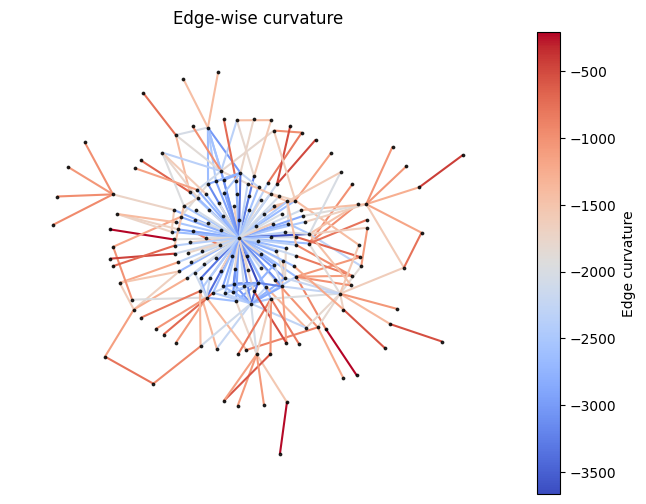

In [245]:
# Idea #3
# Edge weights_{vu} := abs(uv-entry of the Laplacian), ie.: (our) l0 uv-entry
# Node weights_{v} := abs(vv-entry of our l0), ie.: (our) l0 vv-entry

# plotting for a single-layer laplacian
curvature_dict_l0 = forman_weber_curvature(l0_list[layer], degree_weights=False)
# display(curvature_dict_l0)

G = nx.Graph()
G.add_nodes_from(range(l0_list[layer].shape[0]))
G.add_edges_from(sorted(curvature_dict_l0.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0_paper[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

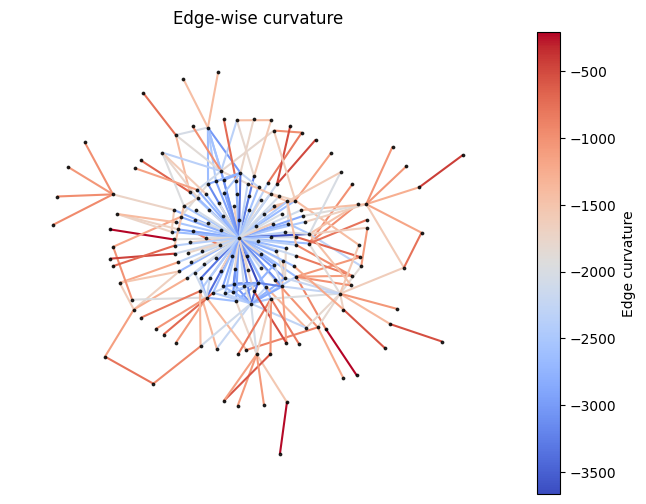

In [ ]:
# Idea #4
# Edge weights_{vu} := abs(uv-entry of the Laplacian), ie.: (our) l0 uv-entry
# Node weights_{v} := abs(vv-entry of the augmented node's degree matrix ^{-1})

# plotting for a single-layer laplacian
curvature_dict_l0 = forman_weber_curvature(l0_list[layer], degree_weights=True)
# display(curvature_dict_l0)

G = nx.Graph()
G.add_nodes_from(list(range(l0_list[layer].shape[0])))
G.add_edges_from(sorted(curvature_dict_l0.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0_paper[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

## 4. To-do List

1. Stesse visualizzazioni, ma usando i pesi
2. Variare sui pesi dei nodi, vedere come si distribuiscono
3. osservare come cambia il grafo visualizzato quando abbiamo diverse combinazioni di layer - layer massimo di diffusione
4. intuizione ML
5. carta e penna se c'è qualcosa di interessante

## ? Future Ideas

1. Analysis of ***Dirichlet energy*** on Graphs, given adjustable curvature